# Plot warm/cold Ac/C eddies

plot difference between warm and cold eddies according to their polarity (maybe one column for ac and c and than the warm/cold in the same plot?)

#### Data import

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
import statsmodels.api as sm


In [2]:
#import combo data fro combined AC/C eddies with r > q75 and e < 20%
edso1_dn23_clt_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20.nc")
edso1_dn23_hfls_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20.nc")
edso1_dn23_hfss_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20.nc")
edso1_dn23_sfcwind_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20.nc")

In [3]:
#import data warm/cold
edso1_clt_q75_e20_warm = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_warm.nc")
edso1_clt_q75_e20_cold = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20_cold.nc")

edso1_hfls_q75_e20_warm = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20_warm.nc")
edso1_hfls_q75_e20_cold = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20_cold.nc")

edso1_hfss_q75_e20_warm = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20_warm.nc")
edso1_hfss_q75_e20_cold = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20_cold.nc")

edso1_sfcwind_q75_e20_warm = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20_warm.nc")
edso1_sfcwind_q75_e20_cold = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20_cold.nc")

FileNotFoundError: [Errno 2] No such file or directory: b'/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20_warm.nc'

In [ ]:
#import data ac/c
edso1_clt_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20.nc")
edso1_clt_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20.nc")

edso1_hfls_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfls_ac_q75_e20.nc")
edso1_hfls_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfls_c_q75_e20.nc")

edso1_hfss_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfss_ac_q75_e20.nc")
edso1_hfss_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_hfss_c_q75_e20.nc")

edso1_sfcwind_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_sfcwind_ac_q75_e20.nc")
edso1_sfcwind_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_sfcwind_c_q75_e20.nc")

In [5]:
edso1_clt_q75_e20_warm

<xarray.Dataset>
Dimensions:                        (obs: 31559, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 422.0 426.0 ... 1.942e+06
    quantile                       float64 ...
    number                         (obs) int64 ...
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 ...
    cost_association               (obs) float32 ...
    effective_area                 (obs) float32 ...
    effective_contour_height       (obs) float32 ...
    effective_contour_latitude     (obs, NbSample) float64 ...
    effective_contour_longitude    (obs, NbSample) float64 ...
    ...                             ...
    sst_mean_ed                    (obs) float64 ...
    sst_npoints_ed                 (obs) float64 ...
    sst_mean_donut                 (obs) float64 ...
    sst_npoints_donut              (obs) float64 ...
    dif_sst                        (obs) float64 ...
    id                             (obs) float64 ...
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

In [6]:
edso1_clt_q75_e20_cold

<xarray.Dataset>
Dimensions:                        (obs: 29227, NbSample: 50)
Coordinates:
  * obs                            (obs) float64 2.411e+03 ... 1.946e+06
    quantile                       float64 ...
    number                         (obs) int64 ...
Dimensions without coordinates: NbSample
Data variables: (12/42)
    amplitude                      (obs) float64 ...
    cost_association               (obs) float32 ...
    effective_area                 (obs) float32 ...
    effective_contour_height       (obs) float32 ...
    effective_contour_latitude     (obs, NbSample) float64 ...
    effective_contour_longitude    (obs, NbSample) float64 ...
    ...                             ...
    sst_mean_ed                    (obs) float64 ...
    sst_npoints_ed                 (obs) float64 ...
    sst_mean_donut                 (obs) float64 ...
    sst_npoints_donut              (obs) float64 ...
    dif_sst                        (obs) float64 ...
    id                             (obs) float64 ...
Attributes: (12/13)
    track_extra_variables:     lat_max,lon_max
    track_array_variables:     50
    array_variables:           contour_lat_e,contour_lon_e,contour_lat_s,cont...
    title:                     Anticyclonic
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    ...                        ...
    framework_version:         0+unknown
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    date_created:              2025-09-05T07:58:08Z
    time_coverage_duration:    P8034D
    time_coverage_start:       1993-01-01T00:00:00Z
    time_coverage_end:         2014-12-31T00:00:00Z

#### DOF Method

In [6]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

def run_effective_regression(ds, y_name, x_name, T=7, alpha=0.05):
    """
    - compute effective sample size (n_eff = n / T)
    - run simple linear regression y ~ x
    - compute Pearson r and R²
    - return full OLS output
    - adjust SE, t, p, CI using n_eff
    - print results rounded to 4 decimals
    """

    #extract data
    ds_single = ds.isel(NbSample=0)
    df = ds_single.to_dataframe().reset_index()

    y = df[y_name]
    X = df[[x_name]]
    X = sm.add_constant(X)

    #effective sample size
    n = len(df)
    n_eff = n / T

    #fit OLS model
    model = sm.OLS(y, X).fit()
    ols_summary_text = model.summary().as_text()

   
    #pearson correlation and R²
    df_clean = df[[x_name, y_name]].dropna()
    r = np.corrcoef(df_clean[x_name], df_clean[y_name])[0, 1]

    R2 = r**2

    #adjust inference
    b = model.params[x_name]
    se_orig = model.bse[x_name]
    k = X.shape[1]

    se_new = se_orig * np.sqrt(n / n_eff)
    t_new = b / se_new
    df_eff = n_eff - k
    p_new = 2 * (1 - stats.t.cdf(abs(t_new), df=df_eff))

    tcrit = stats.t.ppf(1 - alpha/2, df=df_eff)
    ci_low = b - tcrit * se_new
    ci_high = b + tcrit * se_new

    #correlation significance
    t_r = r * np.sqrt((n_eff - 2) / (1 - r**2))
    p_r = 2 * (1 - stats.t.cdf(abs(t_r), df=n_eff - 2))

    #print
    print("\n===== OLS RESULTS (raw) =====")
    print(ols_summary_text)
    
    print("\n===== EFFECTIVE SAMPLE SIZE =====")
    print(f"n      = {n}")
    print(f"n_eff  = {n_eff:.4f}")
    
    print("\n===== CORRELATION =====")
    print(f"r      = {r:.4f}")
    print(f"R²     = {R2:.4f}")
    print(f"t_r    = {t_r:.4f}")
    print(f"p_r    = {p_r:.4f}")
    
    print("\n===== REGRESSION COEFFICIENT (adjusted for n_eff) =====")
    
    # CI half-width for ± notation
    ci_half_width = (ci_high - ci_low) / 2
    
    print(f"beta (± CI)    = {b:.4f} ± {ci_half_width:.4f}")
    #print(f"SE original    = {se_orig:.4f}")
    print(f"SE adjusted    = {se_new:.4f}")
    #print(f"t original     = {model.tvalues[x_name]:.4f}")
    print(f"t adjusted     = {t_new:.4f}")
    #print(f"p original     = {model.pvalues[x_name]:.4f}")
    print(f"p adjusted     = {p_new:.4f}")
    print(f"CI adjusted    = [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"df_eff         = {df_eff:.4f}")

    #return values
    return {
        "n": n,
        "n_eff": n_eff,
        "beta_original": b,
        "se_original": se_orig,
        "t_original": model.tvalues[x_name],
        "p_original": model.pvalues[x_name],
        "ci_original": model.conf_int().loc[x_name].tolist(),
        "beta": b,
        "se_adjusted": se_new,
        "t_adjusted": t_new,
        "p_adjusted": p_new,
        "ci_adjusted": (ci_low, ci_high),
        "df_eff": df_eff,
        "r": r,
        "t_r_adjusted": t_r,
        "p_r_adjusted": p_r,
        "R2": R2,
        "ols_summary": ols_summary_text,
        "model": model
    }


In [8]:
results = run_effective_regression(
    edso1_sfcwind_q75_e20_warm,
    y_name="dif_sfcwind",
    x_name="dif_sst",
    T=7
)



===== OLS RESULTS (raw) =====
                            OLS Regression Results                            
Dep. Variable:            dif_sfcwind   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.597
Date:                Mon, 09 Feb 2026   Prob (F-statistic):              0.206
Time:                        09:34:26   Log-Likelihood:                -41277.
No. Observations:               31559   AIC:                         8.256e+04
Df Residuals:                   31557   BIC:                         8.258e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0427

In [37]:
#calculate effective size with T = 7
#n_eff = n/T

n = edso1_hfls_q75_e20_cold.sizes['obs']
n_eff = n / 7
print(f"Effective sample size (n_eff) = {n_eff:.1f}")

Effective sample size (n_eff) = 4175.3


In [5]:
import numpy as np

def weekly_random_subsample(ds, var_filter, obs_dim="obs", time_dim="time", seed=None):

    ds_flat = ds.isel(NbSample=0)

    if seed is not None:
        np.random.seed(seed)
        
    # Drop observations with NaNs in dif_sst or var_filter
    ds_clean = ds_flat.where(
        np.isfinite(ds_flat["dif_sst"]) &
        np.isfinite(ds_flat[var_filter]),
        drop=True
    )

    # Weekly binning
    time_vals = ds_clean[time_dim].values
    time_min = time_vals.min()

    week_bin = (
        (time_vals - time_min) / np.timedelta64(1, "D") // 7
    ).astype(int)

    # Randomly select one obs per week
    selected_indices = []

    for w in np.unique(week_bin):
        indices_in_bin = np.where(week_bin == w)[0]
        chosen_idx = np.random.choice(indices_in_bin, size=1)[0]
        selected_indices.append(chosen_idx)

    # Subset dataset
    ds_week = ds_clean.isel({obs_dim: selected_indices})

    print(seed)

    return ds_week




In [6]:
#ac selection (warm/cold)
edso1_clt_ac_warm_week = weekly_random_subsample(edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst > 0, drop = True), "dif_clt")
edso1_clt_ac_cold_week = weekly_random_subsample(edso1_clt_ac_q75_e20.where(edso1_clt_ac_q75_e20.dif_sst < 0, drop = True), "dif_clt")

edso1_hfls_ac_warm_week = weekly_random_subsample(edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst > 0, drop = True), "dif_hfls")
edso1_hfls_ac_cold_week = weekly_random_subsample(edso1_hfls_ac_q75_e20.where(edso1_hfls_ac_q75_e20.dif_sst < 0, drop = True), "dif_hfls")

edso1_hfss_ac_warm_week = weekly_random_subsample(edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst > 0, drop = True), "dif_hfss")
edso1_hfss_ac_cold_week = weekly_random_subsample(edso1_hfss_ac_q75_e20.where(edso1_hfss_ac_q75_e20.dif_sst < 0, drop = True), "dif_hfss")

edso1_sfcwind_ac_warm_week = weekly_random_subsample(edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst > 0, drop = True), "dif_sfcwind")
edso1_sfcwind_ac_cold_week = weekly_random_subsample(edso1_sfcwind_ac_q75_e20.where(edso1_sfcwind_ac_q75_e20.dif_sst < 0, drop = True), "dif_sfcwind")

None
None
None
None
None
None
None
None


In [7]:
#c selection (warm/cold)
edso1_clt_c_warm_week = weekly_random_subsample(edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst > 0, drop = True), "dif_clt")
edso1_clt_c_cold_week = weekly_random_subsample(edso1_clt_c_q75_e20.where(edso1_clt_c_q75_e20.dif_sst < 0, drop = True), "dif_clt")

edso1_hfls_c_warm_week = weekly_random_subsample(edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst > 0, drop = True), "dif_hfls")
edso1_hfls_c_cold_week = weekly_random_subsample(edso1_hfls_c_q75_e20.where(edso1_hfls_c_q75_e20.dif_sst < 0, drop = True), "dif_hfls")

edso1_hfss_c_warm_week = weekly_random_subsample(edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst > 0, drop = True), "dif_hfss")
edso1_hfss_c_cold_week = weekly_random_subsample(edso1_hfss_c_q75_e20.where(edso1_hfss_c_q75_e20.dif_sst < 0, drop = True), "dif_hfss")

edso1_sfcwind_c_warm_week = weekly_random_subsample(edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst > 0, drop = True), "dif_sfcwind")
edso1_sfcwind_c_cold_week = weekly_random_subsample(edso1_sfcwind_c_q75_e20.where(edso1_sfcwind_c_q75_e20.dif_sst < 0, drop = True), "dif_sfcwind")

None
None
None
None
None
None
None
None


In [8]:
edso1_clt_warm_week = weekly_random_subsample(edso1_clt_q75_e20_warm, "dif_clt")
edso1_clt_cold_week = weekly_random_subsample(edso1_clt_q75_e20_cold, "dif_clt")

edso1_hfls_warm_week = weekly_random_subsample(edso1_hfls_q75_e20_warm, "dif_hfls")
edso1_hfls_cold_week = weekly_random_subsample(edso1_hfls_q75_e20_cold, "dif_hfls")

edso1_hfss_warm_week = weekly_random_subsample(edso1_hfss_q75_e20_warm, "dif_hfss")
edso1_hfss_cold_week = weekly_random_subsample(edso1_hfss_q75_e20_cold, "dif_hfss")

edso1_sfcwind_warm_week = weekly_random_subsample(edso1_sfcwind_q75_e20_warm, "dif_sfcwind")
edso1_sfcwind_cold_week = weekly_random_subsample(edso1_sfcwind_q75_e20_cold, "dif_sfcwind")

None
None
None
None
None
None
None
None


#### plot scatter

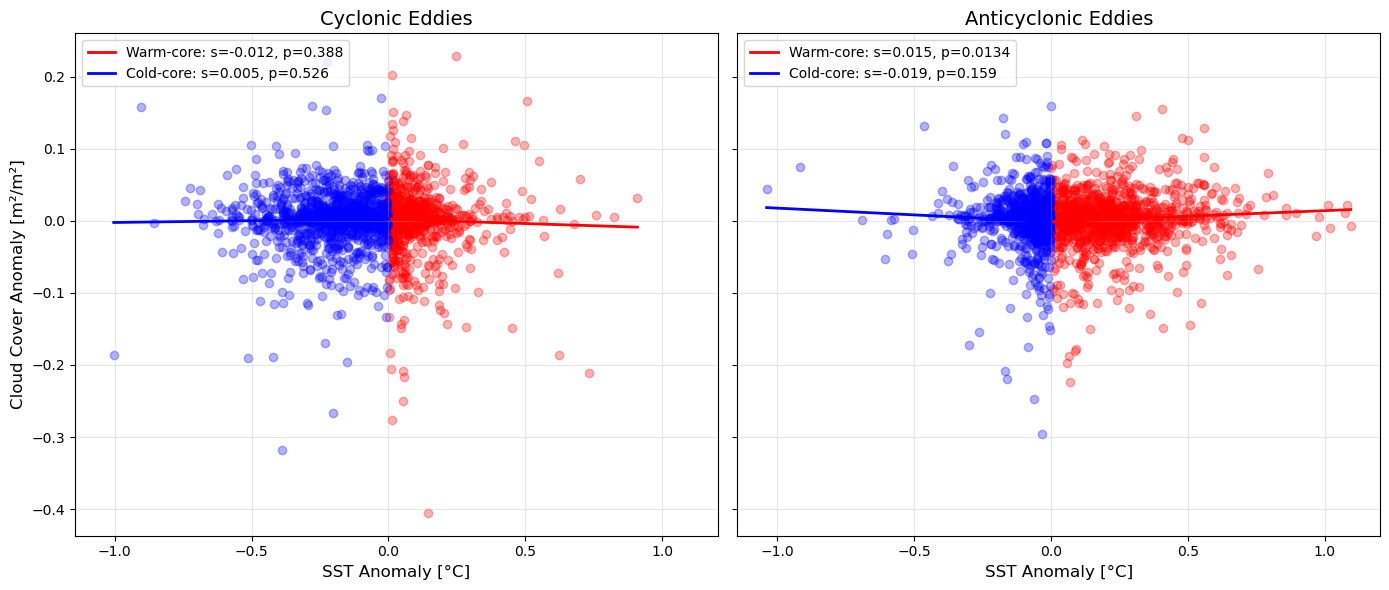

In [53]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# -------------------------
# Cyclonic Eddies
# -------------------------
ax = axes[0]

# Warm-core
x_warm = edso1_clt_c_warm_week['dif_sst']
y_warm = edso1_clt_c_warm_week['dif_clt']
ax.scatter(x_warm, y_warm, color='red', alpha=0.3)

res_warm = linregress(x_warm, y_warm)
x_line = np.linspace(x_warm.min(), x_warm.max(), 100)
ax.plot(x_line, res_warm.intercept + res_warm.slope * x_line, 'r-', lw=2,
        label=f'Warm-core: s={res_warm.slope:.3f}, p={res_warm.pvalue:.3g}')

# Cold-core
x_cold = edso1_clt_c_cold_week['dif_sst']
y_cold = edso1_clt_c_cold_week['dif_clt']
ax.scatter(x_cold, y_cold, color='blue', alpha=0.3)

res_cold = linregress(x_cold, y_cold)
x_line = np.linspace(x_cold.min(), x_cold.max(), 100)
ax.plot(x_line, res_cold.intercept + res_cold.slope * x_line, 'b-', lw=2,
        label=f'Cold-core: s={res_cold.slope:.3f}, p={res_cold.pvalue:.3g}')

ax.set_title("Cyclonic Eddies", fontsize=14)
ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
ax.set_ylabel("Cloud Cover Anomaly [m²/m²]", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

# -------------------------
# Anticyclonic Eddies
# -------------------------
ax = axes[1]

# Warm-core
x_warm = edso1_clt_ac_warm_week['dif_sst']
y_warm = edso1_clt_ac_warm_week['dif_clt']
ax.scatter(x_warm, y_warm, color='red', alpha=0.3)

res_warm = linregress(x_warm, y_warm)
x_line = np.linspace(x_warm.min(), x_warm.max(), 100)
ax.plot(x_line, res_warm.intercept + res_warm.slope * x_line, 'r-', lw=2,
        label=f'Warm-core: s={res_warm.slope:.3f}, p={res_warm.pvalue:.3g}')

# Cold-core
x_cold = edso1_clt_ac_cold_week['dif_sst']
y_cold = edso1_clt_ac_cold_week['dif_clt']
ax.scatter(x_cold, y_cold, color='blue', alpha=0.3)

res_cold = linregress(x_cold, y_cold)
x_line = np.linspace(x_cold.min(), x_cold.max(), 100)
ax.plot(x_line, res_cold.intercept + res_cold.slope * x_line, 'b-', lw=2,
        label=f'Cold-core: s={res_cold.slope:.3f}, p={res_cold.pvalue:.3g}')

ax.set_title("Anticyclonic Eddies", fontsize=14)
ax.set_xlabel("SST Anomaly [°C]", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


#### SST bins

In [6]:
#defining bin edges with width of 0.25° and 0 in the centre
bins = vec = np.arange(-1.5, 1.5 + 0.2, 0.2)

In [8]:
#drop nan
clt_warm_week = edso1_clt_q75_e20_warm.dropna(dim="obs", subset=["dif_sst", "dif_clt"])
clt_cold_week = edso1_clt_q75_e20_cold.dropna(dim="obs", subset=["dif_sst", "dif_clt"])

hfls_warm_week = edso1_hfls_q75_e20_warm.dropna(dim="obs", subset=["dif_sst", "dif_hfls"])
hfls_cold_week = edso1_hfls_q75_e20_cold.dropna(dim="obs", subset=["dif_sst", "dif_hfls"])

hfss_warm_week = edso1_hfss_q75_e20_warm.dropna(dim="obs", subset=["dif_sst", "dif_hfss"])
hfss_cold_week = edso1_hfss_q75_e20_cold.dropna(dim="obs", subset=["dif_sst", "dif_hfss"])

sfcwind_warm_week = edso1_sfcwind_q75_e20_warm.dropna(dim="obs", subset=["dif_sst", "dif_sfcwind"])
sfcwind_cold_week = edso1_sfcwind_q75_e20_cold.dropna(dim="obs", subset=["dif_sst", "dif_sfcwind"])

In [9]:
#calculate mean per bin
clt_warm_mean_week = (clt_warm_week["dif_clt"].groupby_bins(clt_warm_week["dif_sst"], bins).mean(dim="obs"))
clt_cold_mean_week = (clt_cold_week["dif_clt"].groupby_bins(clt_cold_week["dif_sst"], bins).mean(dim="obs"))

hfls_warm_mean_week = (hfls_warm_week["dif_hfls"].groupby_bins(hfls_warm_week["dif_sst"], bins).mean(dim="obs"))
hfls_cold_mean_week = (hfls_cold_week["dif_hfls"].groupby_bins(hfls_cold_week["dif_sst"], bins).mean(dim="obs"))

hfss_warm_mean_week = (hfss_warm_week["dif_hfss"].groupby_bins(hfss_warm_week["dif_sst"], bins).mean(dim="obs"))
hfss_cold_mean_week = (hfss_cold_week["dif_hfss"].groupby_bins(hfss_cold_week["dif_sst"], bins).mean(dim="obs"))

sfcwind_warm_mean_week = (sfcwind_warm_week["dif_sfcwind"].groupby_bins(sfcwind_warm_week["dif_sst"], bins).mean(dim="obs"))
sfcwind_cold_mean_week = (sfcwind_cold_week["dif_sfcwind"].groupby_bins(sfcwind_cold_week["dif_sst"], bins).mean(dim="obs"))

In [10]:
#calculate standard error of the mean
clt_warm_std_week = (clt_warm_week["dif_clt"].groupby_bins(clt_warm_week["dif_sst"], bins).std(dim="obs"))
clt_warm_count_week = (clt_warm_week["dif_clt"].groupby_bins(clt_warm_week["dif_sst"], bins).count(dim="obs"))
clt_warm_sem_week = clt_warm_std_week / np.sqrt(clt_warm_count_week)

clt_cold_std_week = (clt_cold_week["dif_clt"].groupby_bins(clt_cold_week["dif_sst"], bins).std(dim="obs"))
clt_cold_count_week = (clt_cold_week["dif_clt"].groupby_bins(clt_cold_week["dif_sst"], bins).count(dim="obs"))
clt_cold_sem_week = clt_cold_std_week / np.sqrt(clt_cold_count_week)

hfls_warm_std_week = (hfls_warm_week["dif_hfls"].groupby_bins(hfls_warm_week["dif_sst"], bins).std(dim="obs"))
hfls_warm_count_week = (hfls_warm_week["dif_hfls"].groupby_bins(hfls_warm_week["dif_sst"], bins).count(dim="obs"))
hfls_warm_sem_week = hfls_warm_std_week / np.sqrt(hfls_warm_count_week)

hfls_cold_std_week = (hfls_cold_week["dif_hfls"].groupby_bins(hfls_cold_week["dif_sst"], bins).std(dim="obs"))
hfls_cold_count_week = (hfls_cold_week["dif_hfls"].groupby_bins(hfls_cold_week["dif_sst"], bins).count(dim="obs"))
hfls_cold_sem_week = hfls_cold_std_week / np.sqrt(hfls_cold_count_week)

hfss_warm_std_week = (hfss_warm_week["dif_hfss"].groupby_bins(hfss_warm_week["dif_sst"], bins).std(dim="obs"))
hfss_warm_count_week = (hfss_warm_week["dif_hfss"].groupby_bins(hfss_warm_week["dif_sst"], bins).count(dim="obs"))
hfss_warm_sem_week = hfss_warm_std_week / np.sqrt(hfss_warm_count_week)

hfss_cold_std_week = (hfss_cold_week["dif_hfss"].groupby_bins(hfss_cold_week["dif_sst"], bins).std(dim="obs"))
hfss_cold_count_week = (hfss_cold_week["dif_hfss"].groupby_bins(hfss_cold_week["dif_sst"], bins).count(dim="obs"))
hfss_cold_sem_week = hfss_cold_std_week / np.sqrt(hfss_cold_count_week)

sfcwind_warm_std_week = (sfcwind_warm_week["dif_sfcwind"].groupby_bins(sfcwind_warm_week["dif_sst"], bins).std(dim="obs"))
sfcwind_warm_count_week = (sfcwind_warm_week["dif_sfcwind"].groupby_bins(sfcwind_warm_week["dif_sst"], bins).count(dim="obs"))
sfcwind_warm_sem_week = sfcwind_warm_std_week / np.sqrt(sfcwind_warm_count_week)

sfcwind_cold_std_week = (sfcwind_cold_week["dif_sfcwind"].groupby_bins(sfcwind_cold_week["dif_sst"], bins).std(dim="obs"))
sfcwind_cold_count_week = (sfcwind_cold_week["dif_sfcwind"].groupby_bins(sfcwind_cold_week["dif_sst"], bins).count(dim="obs"))
sfcwind_cold_sem_week = sfcwind_cold_std_week / np.sqrt(sfcwind_cold_count_week)



In [11]:
#get bin centeres for plotting
bin_centers = [b.mid for b in clt_warm_mean_week["dif_sst_bins"].values]
bin_centers = np.array(bin_centers)

In [12]:
bin_centers

array([-1.4, -1.2, -1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,
        0.8,  1. ,  1.2,  1.4])

In [13]:
mask_clt_warm = (
    np.isfinite(clt_warm_week["dif_sst"]) &
    np.isfinite(clt_warm_week["dif_clt"])
)

res_clt_warm = linregress(
    clt_warm_week["dif_sst"].values[mask_clt_warm],
    clt_warm_week["dif_clt"].values[mask_clt_warm]
)

mask_clt_cold = (
    np.isfinite(clt_cold_week["dif_sst"]) &
    np.isfinite(clt_cold_week["dif_clt"])
)

res_clt_cold = linregress(
    clt_cold_week["dif_sst"].values[mask_clt_cold],
    clt_cold_week["dif_clt"].values[mask_clt_cold]
)


In [14]:
mask_hfls_warm = (
    np.isfinite(hfls_warm_week["dif_sst"]) &
    np.isfinite(hfls_warm_week["dif_hfls"])
)

res_hfls_warm = linregress(
    hfls_warm_week["dif_sst"].values[mask_hfls_warm],
    hfls_warm_week["dif_hfls"].values[mask_hfls_warm]
)

mask_hfls_cold = (
    np.isfinite(hfls_cold_week["dif_sst"]) &
    np.isfinite(hfls_cold_week["dif_hfls"])
)

res_hfls_cold = linregress(
    hfls_cold_week["dif_sst"].values[mask_hfls_cold],
    hfls_cold_week["dif_hfls"].values[mask_hfls_cold]
)


In [15]:
mask_hfss_warm = (
    np.isfinite(hfss_warm_week["dif_sst"]) &
    np.isfinite(hfss_warm_week["dif_hfss"])
)

res_hfss_warm = linregress(
    hfss_warm_week["dif_sst"].values[mask_hfss_warm],
    hfss_warm_week["dif_hfss"].values[mask_hfss_warm]
)

mask_hfss_cold = (
    np.isfinite(hfss_cold_week["dif_sst"]) &
    np.isfinite(hfss_cold_week["dif_hfss"])
)

res_hfss_cold = linregress(
    hfss_cold_week["dif_sst"].values[mask_hfss_cold],
    hfss_cold_week["dif_hfss"].values[mask_hfss_cold]
)


In [16]:
mask_sfcwind_warm = (
    np.isfinite(sfcwind_warm_week["dif_sst"]) &
    np.isfinite(sfcwind_warm_week["dif_sfcwind"])
)

res_sfcwind_warm = linregress(
    sfcwind_warm_week["dif_sst"].values[mask_sfcwind_warm],
    sfcwind_warm_week["dif_sfcwind"].values[mask_sfcwind_warm]
)

mask_sfcwind_cold = (
    np.isfinite(sfcwind_cold_week["dif_sst"]) &
    np.isfinite(sfcwind_cold_week["dif_sfcwind"])
)

res_sfcwind_cold = linregress(
    sfcwind_cold_week["dif_sst"].values[mask_sfcwind_cold],
    sfcwind_cold_week["dif_sfcwind"].values[mask_sfcwind_cold]
)


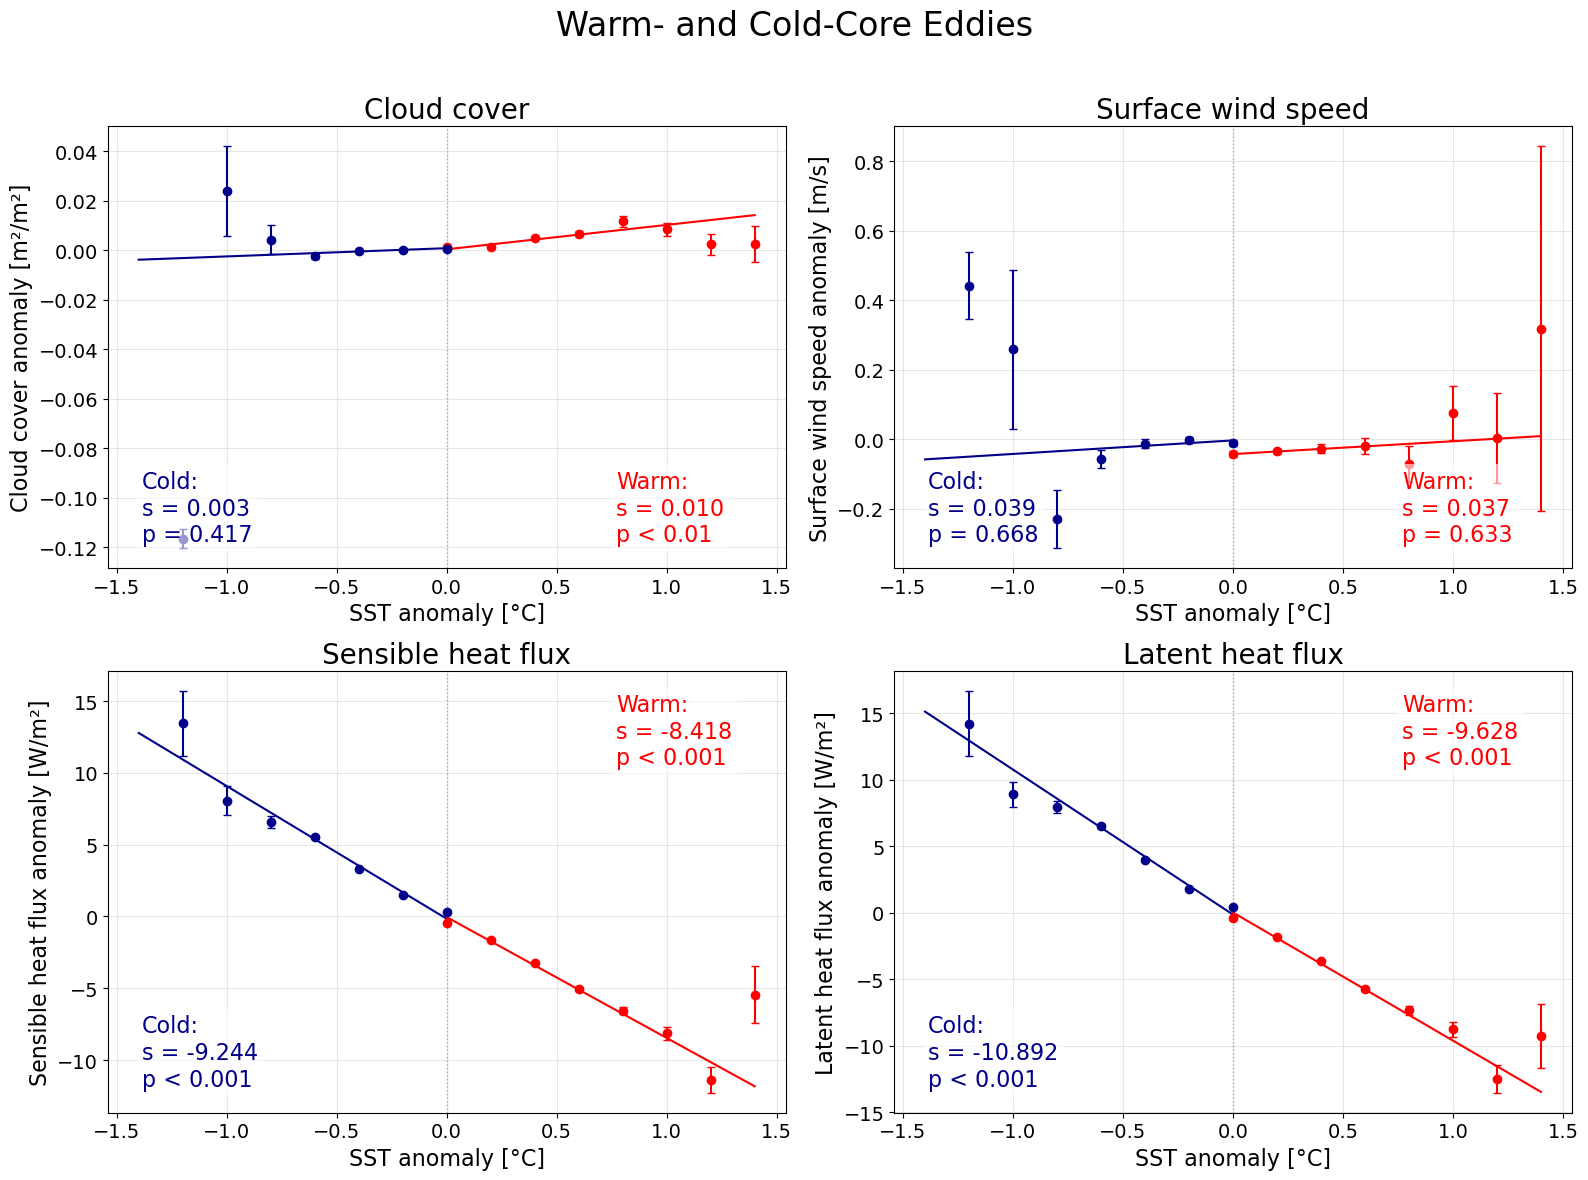

In [21]:
import matplotlib.pyplot as plt
import numpy as np

variables = ["clt", "sfcwind", "hfss", "hfls"]
titles = [
    "Cloud cover anomaly [m²/m²]",
    "Surface wind speed anomaly [m/s]",
    "Sensible heat flux anomaly [W/m²]",
    "Latent heat flux anomaly [W/m²]"
]

pvals_cold = {
    "clt": "p = 0.417",
    "sfcwind": "p = 0.668",
    "hfss": "p < 0.001",
    "hfls": "p < 0.001"
}

pvals_warm = {
    "clt": "p < 0.01",
    "sfcwind": "p = 0.633",
    "hfss": "p < 0.001",
    "hfls": "p < 0.001"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]

    # --- Warm ---
    mean_warm = globals()[f"{var}_warm_mean_week"].values
    sem_warm  = globals()[f"{var}_warm_sem_week"].values
    res_warm  = globals()[f"res_{var}_warm"]

    # --- Cold ---
    mean_cold = globals()[f"{var}_cold_mean_week"].values
    sem_cold  = globals()[f"{var}_cold_sem_week"].values
    res_cold  = globals()[f"res_{var}_cold"]

    # --- Binned means ---
    ax.errorbar(
        bin_centers, mean_warm, yerr=sem_warm,
        fmt="o", capsize=3, color="red", label="Warm"
    )
    ax.errorbar(
        bin_centers, mean_cold, yerr=sem_cold,
        fmt="o", capsize=3, color="darkblue", label="Cold"
    )

    # --- Regression lines ---
    # Split x-range at 0
    x_neg = np.linspace(bin_centers.min(), 0, 100)
    x_pos = np.linspace(0, bin_centers.max(), 100)
    
    # Cold (blue): only negative SST anomalies
    ax.plot(
        x_neg,
        res_cold.intercept + res_cold.slope * x_neg,
        color="darkblue", lw=1.5
    )
    
    # Warm (red): only positive SST anomalies
    ax.plot(
        x_pos,
        res_warm.intercept + res_warm.slope * x_pos,
        color="red", lw=1.5
    )


   # --- Text box placement ---
    if i < 2:  # TOP ROW
    # Cold (bottom-left)
        ax.text(
            0.05, 0.05,     
            "Cold:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"{pvals_cold[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="darkblue",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        # Warm (bottom-right)
        ax.text(
            0.75, 0.05,
            "Warm:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"{pvals_warm[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="red",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    else:  # BOTTOM ROW
    # Cold (bottom-left)
        ax.text(
            0.05, 0.05,
            "Cold:\n"
            f"s = {res_cold.slope:.3f}\n"
            f"{pvals_cold[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="darkblue",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
        # Warm (top-right)
        ax.text(
            0.75, 0.95,
            "Warm:\n"
            f"s = {res_warm.slope:.3f}\n"
            f"{pvals_warm[var]}",
            transform=ax.transAxes,
            fontsize=16,
            color="red",
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )


    
    # --- Labels ---
    clean_title = titles[i].split("anomaly")[0].strip()
    ax.axvline(0, color="gray", lw=1, ls=":", alpha=0.6)
    ax.set_title(clean_title, fontsize=20)
    ax.set_xlabel("SST anomaly [°C]", fontsize=16)
    ax.set_ylabel(titles[i], fontsize=16)

    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=14)

    
plt.suptitle("Warm- and Cold-Core Eddies", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eddy_obs_sstbins_warm_cold.pdf", bbox_inches="tight")
plt.show()
